# Exploratory Data Analysis (EDA)

In [31]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

In [32]:
spark = (
    SparkSession.builder
    .appName("BusServiceReliability")
    .master("local[*]")
    .getOrCreate()
)

In [33]:
df = spark.read.parquet("../outputs/cleaned_timetable_parquet")

In [34]:
df.show(5, truncate=False)

+-------------------------------------------------------------------------------------------------------+----------+----------+------------+-------------+----------+
|filename                                                                                               |journey_id|operator  |service_code|stop_sequence|route_size|
+-------------------------------------------------------------------------------------------------------+----------+----------+------------+-------------+----------+
|10A-None--SCMY-GM-2026-07-26-Gillmoss_July_2026_EV_ADDED_FINAL__SCMY_PC1033334_5_20260719-BODS_V1_1.xml|VJ2904    |Stagecoach|PC1033334:5 |55           |Long      |
|10A-None--SCMY-GM-2026-07-26-Gillmoss_July_2026_EV_ADDED_FINAL__SCMY_PC1033334_5_20260719-BODS_V1_1.xml|VJ2904    |Stagecoach|PC1033334:5 |56           |Long      |
|10A-None--SCMY-GM-2026-07-26-Gillmoss_July_2026_EV_ADDED_FINAL__SCMY_PC1033334_5_20260719-BODS_V1_1.xml|VJ2904    |Stagecoach|PC1033334:5 |57           |Long      |
|10A

## Dataset Summary

In [20]:
print("Number of rows:", df.count())
print("Number of columns:", len(df.columns))

Number of rows: 271552
Number of columns: 6


## Statistical Measures (Mean, Median, Std, Skewness, Kurtosis)

In [35]:
from pyspark.sql.functions import mean, stddev, skewness, kurtosis, expr

df.select(
    mean("stop_sequence").alias("mean"),
    expr("percentile_approx(stop_sequence, 0.5)").alias("median"),
    stddev("stop_sequence").alias("std_dev"),
    skewness("stop_sequence").alias("skewness"),
    kurtosis("stop_sequence").alias("kurtosis")
).show()

[Stage 51:======================================>                  (8 + 4) / 12]

+------------------+------+------------------+------------------+------------------+
|              mean|median|           std_dev|          skewness|          kurtosis|
+------------------+------+------------------+------------------+------------------+
|26.025019149186896|    22|19.763537454464057|1.0441318799333827|0.8015000270643191|
+------------------+------+------------------+------------------+------------------+



## Data Quality Assessment — Null Counts

In [40]:
from pyspark.sql.functions import col, count, when

null_counts = df.select([
    count(when(col(c).isNull(), c)).alias(c) for c in df.columns
])
null_counts.show(truncate=False)

+--------+----------+--------+------------+-------------+----------+
|filename|journey_id|operator|service_code|stop_sequence|route_size|
+--------+----------+--------+------------+-------------+----------+
|0       |0         |0       |0           |0            |0         |
+--------+----------+--------+------------+-------------+----------+



## Data Quality Assessment — Cardinality

In [41]:
from pyspark.sql.functions import countDistinct

cardinality = df.select([
    countDistinct(col(c)).alias(c) for c in df.columns
])
cardinality.show(truncate=False)

[Stage 69:==============>                                          (3 + 9) / 12]

+--------+----------+--------+------------+-------------+----------+
|filename|journey_id|operator|service_code|stop_sequence|route_size|
+--------+----------+--------+------------+-------------+----------+
|123     |3087      |1       |122         |114          |3         |
+--------+----------+--------+------------+-------------+----------+



## Outlier Detection (IQR Method) — Stop Sequence

In [42]:
q1, q3 = df.approxQuantile("stop_sequence", [0.25, 0.75], 0.01)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

outliers = df.filter((col("stop_sequence") < lower_bound) | (col("stop_sequence") > upper_bound))
print("Number of outlier rows:", outliers.count())
outliers.select("service_code", "journey_id", "stop_sequence").show(10, truncate=False)

Q1: 10.0, Q3: 36.0, IQR: 26.0
Lower bound: -29.0, Upper bound: 75.0
Number of outlier rows: 5664
+-------------+----------+-------------+
|service_code |journey_id|stop_sequence|
+-------------+----------+-------------+
|PC1033334:113|VJ2626    |76           |
|PC1033334:224|VJ1007    |76           |
|PC1033334:224|VJ1010    |76           |
|PC1033334:224|VJ1013    |76           |
|PC1033334:224|VJ1013    |77           |
|PC1033334:224|VJ1013    |78           |
|PC1033334:224|VJ1013    |79           |
|PC1033334:224|VJ1013    |80           |
|PC1033334:224|VJ1015    |76           |
|PC1033334:224|VJ1015    |77           |
+-------------+----------+-------------+
only showing top 10 rows


## Correlation Analysis

In [43]:
from pyspark.sql.functions import max as spark_max, count as spark_count

journey_features = df.groupBy("journey_id", "route_size").agg(
    spark_max("stop_sequence").alias("max_stop_sequence"),
    spark_count("stop_sequence").alias("num_stops")
)
journey_features.show(10, truncate=False)

[Stage 83:=======================>                                 (5 + 7) / 12]

+----------+----------+-----------------+---------+
|journey_id|route_size|max_stop_sequence|num_stops|
+----------+----------+-----------------+---------+
|VJ827     |Short     |19               |25       |
|VJ92      |Medium    |49               |105      |
|VJ150     |Short     |19               |95       |
|VJ159     |Short     |19               |93       |
|VJ252     |Medium    |49               |48       |
|VJ272     |Medium    |49               |78       |
|VJ2953    |Short     |19               |19       |
|VJ1682    |Short     |19               |30       |
|VJ822     |Short     |19               |25       |
|VJ266     |Short     |19               |84       |
+----------+----------+-----------------+---------+
only showing top 10 rows


In [44]:
correlation = journey_features.corr("max_stop_sequence", "num_stops")
print(f"Correlation between max_stop_sequence and num_stops: {correlation:.3f}")

Correlation between max_stop_sequence and num_stops: 0.010


In [45]:
journey_features_fixed = df.groupBy("journey_id", "service_code", "filename", "route_size").agg(
    spark_max("stop_sequence").alias("max_stop_sequence"),
    spark_count("stop_sequence").alias("num_stops")
)

correlation_fixed = journey_features_fixed.corr("max_stop_sequence", "num_stops")
print(f"Correlation (fixed grouping): {correlation_fixed:.3f}")

[Stage 92:============================>                            (6 + 6) / 12]

Correlation (fixed grouping): 0.527


## Route Size Distribution

In [22]:
df.groupBy("route_size").count().orderBy("route_size").show()

+----------+------+
|route_size| count|
+----------+------+
|      Long| 37157|
|    Medium|111318|
|     Short|123077|
+----------+------+



## Top 10 Routes with the Most Stops

In [36]:
df.groupBy("service_code", "route_size") \
  .agg(max("stop_sequence").alias("max_stop_sequence")) \
  .orderBy(desc("max_stop_sequence")) \
  .show(10, truncate=False)

+-------------+----------+-----------------+
|service_code |route_size|max_stop_sequence|
+-------------+----------+-----------------+
|PC1033334:185|Long      |114              |
|PC1033334:113|Long      |104              |
|PC1033334:584|Long      |96               |
|PC1033334:535|Long      |95               |
|PC1033334:186|Long      |88               |
|PC1033334:450|Long      |84               |
|PC1033334:224|Long      |80               |
|PC1033334:196|Long      |78               |
|PC1033334:593|Long      |71               |
|PC1033334:5  |Long      |68               |
+-------------+----------+-----------------+
only showing top 10 rows


## Top 10 Routes with the Highest Number of Journeys

In [38]:
from pyspark.sql.functions import countDistinct, desc

df.groupBy("service_code") \
  .agg(countDistinct("journey_id").alias("num_journeys")) \
  .orderBy(desc("num_journeys")) \
  .show(10, truncate=False)

+-------------+------------+
|service_code |num_journeys|
+-------------+------------+
|PC1033334:15 |574         |
|PC1033334:198|506         |
|PC1033334:106|448         |
|PC1033334:120|403         |
|PC1033334:12 |382         |
|PC1033334:3  |338         |
|PC1033334:14 |336         |
|PC1033334:186|291         |
|PC1033334:196|286         |
|PC1033334:5  |275         |
+-------------+------------+
only showing top 10 rows


## Operator Distribution

In [25]:
df.groupBy("operator").count().show(truncate=False)

+----------+------+
|operator  |count |
+----------+------+
|Stagecoach|271552|
+----------+------+



## Route Size Distribution Visualization

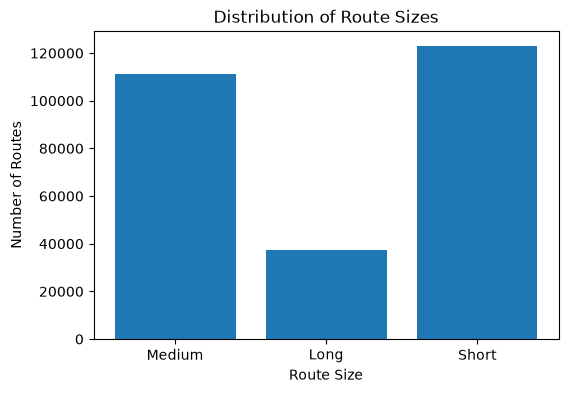

In [26]:
route_counts = df.groupBy("route_size").count().toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(route_counts["route_size"], route_counts["count"])
plt.title("Distribution of Route Sizes")
plt.xlabel("Route Size")
plt.ylabel("Number of Routes")
plt.show()

## Number of Stops Distribution

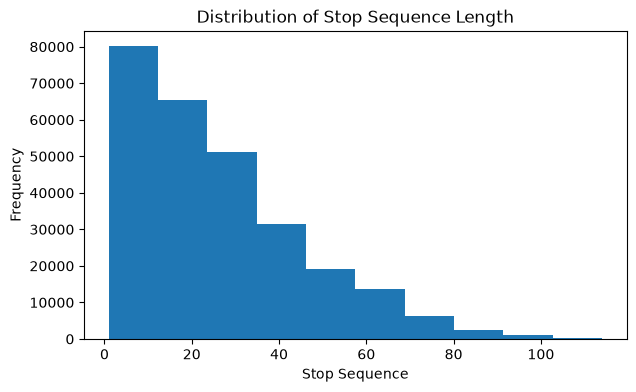

In [27]:
stops = df.select("stop_sequence").toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(stops["stop_sequence"], bins=10)

plt.title("Distribution of Stop Sequence Length")
plt.xlabel("Stop Sequence")
plt.ylabel("Frequency")

plt.show()

## Number of Journeys Distribution

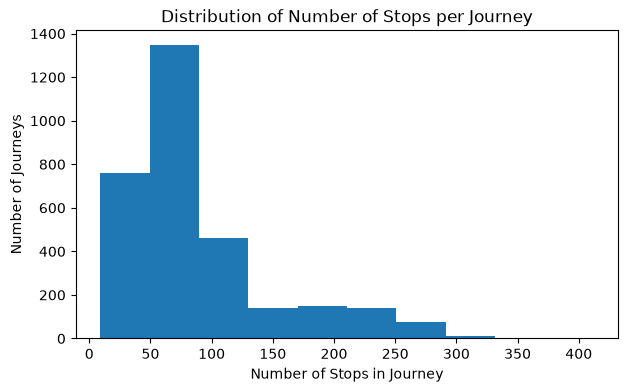

In [39]:
from pyspark.sql.functions import count as spark_count

journeys = df.groupBy("journey_id").agg(spark_count("stop_sequence").alias("num_stops")).toPandas()

import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
plt.hist(journeys["num_stops"], bins=10)
plt.title("Distribution of Number of Stops per Journey")
plt.xlabel("Number of Stops in Journey")
plt.ylabel("Number of Journeys")
plt.show()